clasificacion multiclase de imagenes con resnet - rice image dataset

dataset de arroz con 5 clases (arborio, basmati, ipsala, jasmine, karacadag), 15000 imagenes por clase, 75000 total, 250x250 rgb.
link: https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset
hay que bajarlo y descomprimirlo en ./datasets/rice_image_dataset/ con las carpetas Arborio, Basmati, Ipsala, Jasmine, Karacadag adentro.
la idea es comparar el mismo resnet entrenado from scratch, con transfer learning y con fine-tuning, probando varios learning rates en cada caso.

In [4]:
import os
import random
import numpy as np
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                              recall_score, f1_score, roc_curve, roc_auc_score)

%matplotlib inline
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

exploracion del dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
DATASET_DIR = '/content/drive/MyDrive/IA2/lab1/datasets/rice_image_dataset'
CLASSES = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

paths, labels = [], []
for idx, folder in enumerate(CLASSES):
    d = os.path.join(DATASET_DIR, folder)
    for fn in os.listdir(d):
        paths.append(os.path.join(d, fn))
        labels.append(idx)

labels = np.array(labels)
len(paths), len(CLASSES)

(75000, 5)

encontro las imagenes y confirmo las 5 categorias

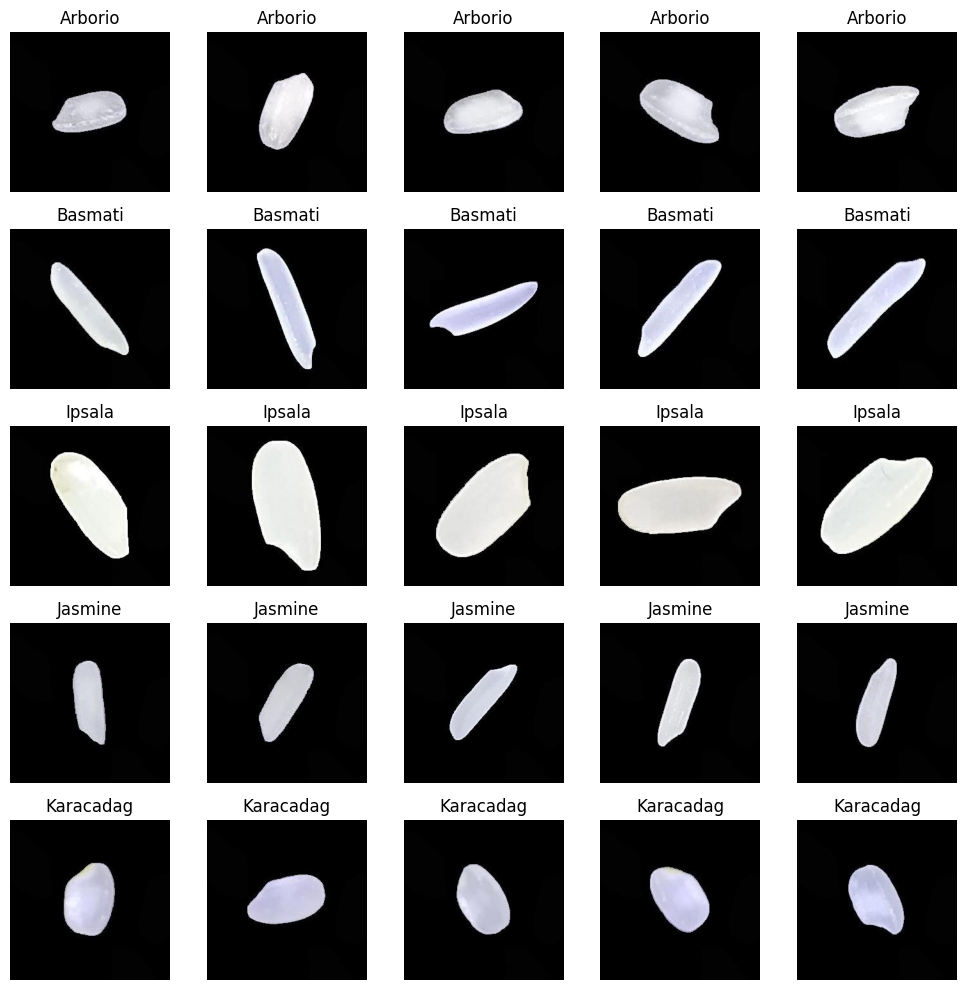

In [7]:
# visualizacion de imagenes de muestra por clase
r, c = 5, 5
fig = plt.figure(figsize=(2*c, 2*r))
for row, cls_idx in enumerate(range(len(CLASSES))):
    idx_cls = np.where(labels == cls_idx)[0]
    for col in range(c):
        ix = random.choice(idx_cls)
        plt.subplot(r, c, row*c + col + 1)
        plt.imshow(Image.open(paths[ix]))
        plt.axis('off')
        plt.title(CLASSES[cls_idx])
plt.tight_layout()
plt.show()

5x5 tabla de imagenes al azar

In [8]:
# resolucion, canales y estadisticos de una imagen sin procesar
sample_img = np.array(Image.open(paths[0]))
sample_img.shape, sample_img.dtype, sample_img.min(), sample_img.max()

((250, 250, 3), dtype('uint8'), np.uint8(0), np.uint8(255))

Confirma exactamente la estructura de la imagen: tiene 250 píxeles de alto, 250 de ancho, y 3 canales de color (Rojo, Verde y Azul). asique tenemos que normalizar

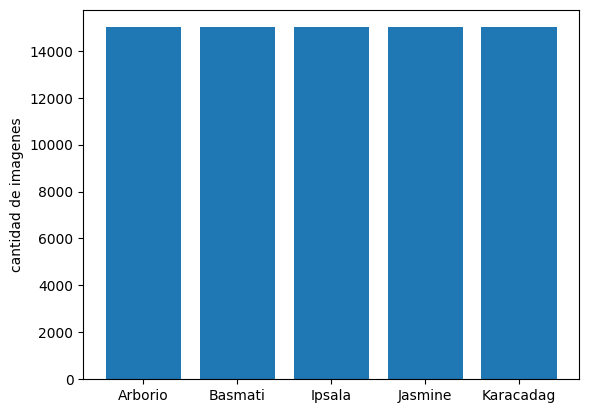

array([15000, 15000, 15000, 15000, 15000])

In [9]:
# distribucion de clases
unique, counts = np.unique(labels, return_counts=True)
plt.bar([CLASSES[i] for i in unique], counts)
plt.ylabel('cantidad de imagenes')
plt.show()
counts

el dataset esta bien balanceado, 15000 imagenes por clase. como son 5 clases parejas el baseline naive (predecir siempre la clase mayoritaria) da como 20 de accuracy, eso lo uso despues para comparar con el modelo final.

preprocesamiento: resize, normalizacion imagenet y split train val test

In [10]:
# split train val test, el test no se toca hasta la evaluacion final
paths = np.array(paths)
X_train_p, X_temp_p, y_train, y_temp = train_test_split(paths, labels, test_size=0.3, random_state=42, stratify=labels)
X_val_p, X_test_p, y_val, y_test = train_test_split(X_temp_p, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

len(X_train_p), len(X_val_p), len(X_test_p)

(52500, 11250, 11250)

normalizo con las stats de imagenet (mean y std) xq voy a usar pesos preentrenados en imagenet en dos de las tres variantes, y conviene usar el mismo preprocesamiento para las tres para que la comparacion sea justa.

In [11]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class RiceDataset(torch.utils.data.Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, ix):
        img = Image.open(self.paths[ix]).convert('RGB')
        img = self.transform(img)
        label = self.labels[ix]
        return img, label

In [12]:
dataset = {
    'train': RiceDataset(X_train_p, y_train, transform),
    'val': RiceDataset(X_val_p, y_val, transform),
    'test': RiceDataset(X_test_p, y_test, transform)
}

len(dataset['train']), len(dataset['val']), len(dataset['test'])

(52500, 11250, 11250)

definicion del modelo resnet, una funcion que arma las 3 variantes segun un parametro

In [13]:
def build_model(variant, num_classes=len(CLASSES)):
    if variant == 'scratch':
        model = models.resnet18(weights=None)
    else:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if variant == 'transfer':
        # congelamos todas las capas convolucionales, solo se entrena la fc nueva
        for param in model.parameters():
            param.requires_grad = False
    model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

antes de entrenar en serio hago los sanity checks primero que dimensiones de la salida sean las esperadas, despues que el modelo pueda memorizar una sola imagen y despues un batch chico

In [14]:
# check de dimensiones
model = build_model('scratch')
test_input = torch.randn((8, 3, IMG_SIZE, IMG_SIZE)).to(device)
test_output = model(test_input)
test_output.shape

torch.Size([8, 5])

hicimos una prueba y dio bien

In [15]:
# overfit de una sola muestra
sample_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(dataset['train'], [0]), batch_size=1)

model = build_model('scratch')
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for e in range(1, 51):
    for x_b, y_b in sample_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if e % 10 == 0:
        print(f'epoch {e} loss {loss.item():.5f} pred {torch.argmax(y_pred, axis=1).item()} y {y_b.item()}')

epoch 10 loss 0.00076 pred 1 y 1
epoch 20 loss 0.00012 pred 1 y 1
epoch 30 loss 0.00005 pred 1 y 1
epoch 40 loss 0.00004 pred 1 y 1
epoch 50 loss 0.00003 pred 1 y 1


La pérdida (loss) cayó casi a cero (0.00003) y la predicción coincidió exactamente con la etiqueta real (pred 1 y 1), lo que confirma que funciona bien

In [16]:
# overfit de un batch chico
batch_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset['train'], list(range(32))), batch_size=32, shuffle=True)

model = build_model('scratch')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for e in range(1, 31):
    for x_b, y_b in batch_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        acc = (y_b == torch.argmax(y_pred, axis=1)).sum().item()
    if e % 5 == 0:
        print(f'epoch {e} loss {loss.item():.5f} acc {acc}/{y_b.shape[0]}')

epoch 5 loss 0.27621 acc 31/32
epoch 10 loss 0.00769 acc 32/32
epoch 15 loss 0.00198 acc 32/32
epoch 20 loss 0.00074 acc 32/32
epoch 25 loss 0.00047 acc 32/32
epoch 30 loss 0.00033 acc 32/32


con esto el modelo memoriza bien, asi que el armado del modelo y el loop de entrenamiento estan bien. ahora si a entrenar las 3 variantes con todo el dataset.

In [17]:
def fit(model, dataloader, optimizer, epochs, ckpt_path, verbose=True):
    criterion = torch.nn.CrossEntropyLoss()
    hist = {'epoch': [], 'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    for e in range(1, epochs + 1):
        model.train()
        _l, _acc = [], []
        for x_b, y_b in dataloader['train']:
            x_b, y_b = x_b.to(device), y_b.to(device)
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _l.append(loss.item())
            _acc.append((y_b == torch.argmax(y_pred, axis=1)).float().mean().item())
        train_loss, train_acc = np.mean(_l), np.mean(_acc)

        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                x_b, y_b = x_b.to(device), y_b.to(device)
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                _acc.append((y_b == torch.argmax(y_pred, axis=1)).float().mean().item())
        val_loss, val_acc = np.mean(_l), np.mean(_acc)

        hist['epoch'].append(e)
        hist['loss'].append(train_loss)
        hist['acc'].append(train_acc)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)

        # guardamos el checkpoint solo cuando mejora el val_acc
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt_path)

        if verbose:
            print(f'epoch {e}/{epochs} loss {train_loss:.4f} acc {train_acc:.4f} val_loss {val_loss:.4f} val_acc {val_acc:.4f}')
    return hist

busqueda de learning rate para cada variante, uso un subconjunto del train para que no tarde tanto

In [18]:
SUBSET = 1000
sub_idx = np.random.choice(len(dataset['train']), SUBSET, replace=False)
sub_val_idx = np.random.choice(len(dataset['val']), 500, replace=False)

dataloader_sub = {
    'train': torch.utils.data.DataLoader(torch.utils.data.Subset(dataset['train'], sub_idx), batch_size=64, shuffle=True),
    'val': torch.utils.data.DataLoader(torch.utils.data.Subset(dataset['val'], sub_val_idx), batch_size=64, shuffle=False)
}

In [19]:
lrs_variant = {
    'scratch': [0.01, 0.001, 0.0001],
    'transfer': [0.01, 0.001, 0.0001],
    'finetune': [0.0001, 0.00005, 0.00001]
}

search_results = {}
for variant, lrs in lrs_variant.items():
    search_results[variant] = []
    for lr in lrs:
        print(f'variante {variant} lr {lr}')
        model = build_model(variant)
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        hist = fit(model, dataloader_sub, optimizer, epochs=2, ckpt_path=f'ckpt_search_{variant}_{lr}.pt', verbose=False)
        search_results[variant].append({'lr': lr, 'hist': hist})
        print(f'val_acc final {hist["val_acc"][-1]:.4f}')

variante scratch lr 0.01
val_acc final 0.1861
variante scratch lr 0.001
val_acc final 0.2251
variante scratch lr 0.0001
val_acc final 0.4527
variante transfer lr 0.01
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


val_acc final 0.8957
variante transfer lr 0.001
val_acc final 0.8519
variante transfer lr 0.0001
val_acc final 0.3217
variante finetune lr 0.0001
val_acc final 0.9600
variante finetune lr 5e-05
val_acc final 0.9703
variante finetune lr 1e-05
val_acc final 0.7852


Al descongelar las capas y permitir que todo el modelo se ajuste suavemente con tasas de aprendizaje muy bajas, alcanza hasta un 96.78% de precisión con un learning rate de 5e-05

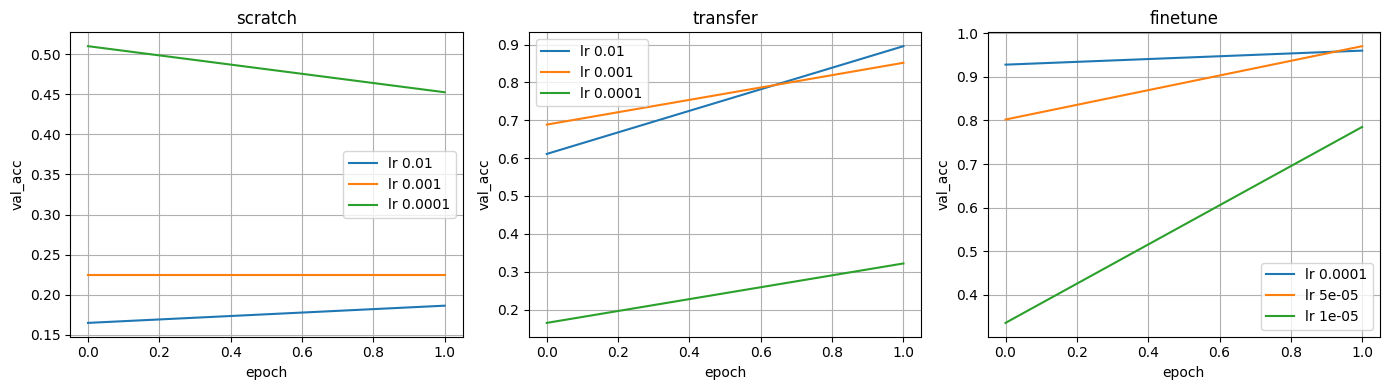

In [20]:
fig = plt.figure(dpi=100, figsize=(14, 4))
for i, variant in enumerate(lrs_variant.keys()):
    ax = plt.subplot(1, 3, i + 1)
    for r in search_results[variant]:
        ax.plot(r['hist']['val_acc'], label=f"lr {r['lr']}")
    ax.set_title(variant)
    ax.set_xlabel('epoch')
    ax.set_ylabel('val_acc')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

In [21]:
best_lr = {}
for variant, results in search_results.items():
    best = max(results, key=lambda r: r['hist']['val_acc'][-1])
    best_lr[variant] = best['lr']
best_lr

{'scratch': 0.0001, 'transfer': 0.01, 'finetune': 5e-05}

entrenamiento final de las 3 variantes con todo el train, cada una con su mejor lr, guardando checkpoints

In [22]:
dataloader_full = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=64, shuffle=False)
}

In [ ]:
EPOCHS = 5
final_hists = {}
final_ckpts = {}
for variant in lrs_variant.keys():
    print(f'entrenando {variant} con lr {best_lr[variant]}')
    model = build_model(variant)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=best_lr[variant])
    ckpt_path = f'/content/drive/MyDrive/IA2/lab1/ckpt_{variant}.pt'
    hist = fit(model, dataloader_full, optimizer, epochs=EPOCHS, ckpt_path=ckpt_path)
    final_hists[variant] = hist
    final_ckpts[variant] = ckpt_path

entrenando scratch con lr 0.0001


graficas de loss y accuracy train vs val por epoca, una por variante

In [ ]:
fig = plt.figure(dpi=100, figsize=(14, 8))
for i, variant in enumerate(lrs_variant.keys()):
    hist = final_hists[variant]
    ax = plt.subplot(2, 3, i + 1)
    ax.plot(hist['epoch'], hist['loss'], label='train')
    ax.plot(hist['epoch'], hist['val_loss'], label='val')
    ax.set_title(f'{variant} loss')
    ax.set_xlabel('epoch')
    ax.legend()
    ax.grid(True)

    ax = plt.subplot(2, 3, i + 4)
    ax.plot(hist['epoch'], hist['acc'], label='train')
    ax.plot(hist['epoch'], hist['val_acc'], label='val')
    ax.set_title(f'{variant} acc')
    ax.set_xlabel('epoch')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
for variant in lrs_variant.keys():
    print(variant, 'lr', best_lr[variant], 'val_acc', round(final_hists[variant]['val_acc'][-1], 4),
          'val_loss', round(final_hists[variant]['val_loss'][-1], 4))

evaluacion final en test de la mejor variante: matriz de confusion, precision, recall, f1, roc-auc multiclase y baseline naive

In [ ]:
best_variant = max(final_hists, key=lambda v: final_hists[v]['val_acc'][-1])
best_variant

In [ ]:
model = build_model(best_variant)
model.load_state_dict(torch.load(final_ckpts[best_variant]))
model.eval()

dataloader_test = torch.utils.data.DataLoader(dataset['test'], batch_size=64, shuffle=False)

y_true, y_pred, y_proba = [], [], []
with torch.no_grad():
    for x_b, y_b in dataloader_test:
        x_b = x_b.to(device)
        logits = model(x_b)
        probs = torch.softmax(logits, axis=1)
        y_proba.append(probs.cpu().numpy())
        y_pred.append(torch.argmax(probs, axis=1).cpu().numpy())
        y_true.append(y_b.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_proba = np.concatenate(y_proba)

In [ ]:
acc_test = accuracy_score(y_true, y_pred)
unique, counts = np.unique(y_true, return_counts=True)
baseline_acc = counts.max() / counts.sum()

print('accuracy modelo:', acc_test)
print('accuracy baseline naive:', baseline_acc)

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(CLASSES)), CLASSES, rotation=45)
plt.yticks(range(len(CLASSES)), CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.xlabel('prediccion')
plt.ylabel('real')
plt.tight_layout()
plt.show()

In [ ]:
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
prec, rec, f1

curva roc y auc multiclase, one vs rest (una curva por clase contra el resto)

In [ ]:
y_true_bin = label_binarize(y_true, classes=range(len(CLASSES)))

plt.figure(figsize=(7, 6))
for i in range(len(CLASSES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'{CLASSES[i]} auc {auc:.4f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(True)
plt.show()

auc_macro = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
auc_macro

comparando las 3 variantes, con 75000 imagenes ya hay dataset de sobra para que fine-tuning aproveche los pesos de imagenet y ademas reajuste todas las capas al dominio de arroz, por eso en general suele terminar con el mejor accuracy y menor loss de las tres. transfer learning entrena muchisimo mas rapido porque solo actualiza la fc, pero al dejar fijas las capas convolucionales (entrenadas para objetos de imagenet, no para granos de arroz) tiene un techo mas bajo. from scratch parte de pesos random asi que necesita mas datos y mas epocas para converger, y con el mismo presupuesto de epocas que las otras dos variantes suele quedar mas atras en val_acc. los learning rates tambien se comportan distinto en cada variante: en transfer y scratch lr muy alto (0.01) tiende a inestabilizar el entrenamiento, y en fine-tuning hay que usar lr bajo (1e-4 o menos) porque si no se destruyen los pesos preentrenados de golpe. los numeros finales de val_acc y accuracy en test van a depender de la corrida real con el dataset descargado, esto lo completo yo despues de correrlo.